# Advanced Telco Churn Modeling and Retention Strategy

## 📌 Project Context

This notebook builds on the previous telco churn prediction and retention strategy work.

The goal of this phase is to improve the project with advanced modeling, explainability, customer risk scoring, and deployment-ready outputs.

Instead of repeating the full data cleaning and exploratory analysis process, this notebook uses the processed dataset created from the earlier project stages.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load processed dataset
file_path = "/kaggle/input/notebooks/myrazd/telco-customer-churn-prediction/processed_telco_churn.csv"

df = pd.read_csv(file_path)

df.head()

,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,...,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Label,Customer_Value_Proxy_MYR,Churn_Probability,Customer_Segment,Priority_Score,Recommended_Action
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,Yes,107.7,0.543726,Low Value + High Risk,58.559316,Use low-cost retention action
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,Yes,141.4,0.846154,Low Value + High Risk,119.646154,Use low-cost retention action
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,99.65,820.50,Yes,797.2,0.846154,Low Value + High Risk,674.553846,Use low-cost retention action
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,104.80,3046.05,Yes,2934.4,0.076923,High Value + Low Risk,225.723077,Maintain relationship
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,5081.3,0.007067,High Value + Low Risk,35.910247,Maintain relationship


In [3]:
# Check dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 25


In [4]:
# Check columns
df.columns

Index(['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label',
       'Customer_Value_Proxy_MYR', 'Churn_Probability', 'Customer_Segment',
       'Priority_Score', 'Recommended_Action'],
      dtype='object')

In [5]:
# Quick data check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    7043 non-null   object 
 1   Senior_Citizen            7043 non-null   object 
 2   Partner                   7043 non-null   object 
 3   Dependents                7043 non-null   object 
 4   Tenure_Months             7043 non-null   int64  
 5   Phone_Service             7043 non-null   object 
 6   Multiple_Lines            7043 non-null   object 
 7   Internet_Service          7043 non-null   object 
 8   Online_Security           7043 non-null   object 
 9   Online_Backup             7043 non-null   object 
 10  Device_Protection         7043 non-null   object 
 11  Tech_Support              7043 non-null   object 
 12  Streaming_TV              7043 non-null   object 
 13  Streaming_Movies          7043 non-null   object 
 14  Contract

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

Gender               0
Senior_Citizen       0
Partner              0
Dependents           0
Tenure_Months        0
Phone_Service        0
Multiple_Lines       0
Internet_Service     0
Online_Security      0
Online_Backup        0
Device_Protection    0
Tech_Support         0
Streaming_TV         0
Streaming_Movies     0
Contract             0
Paperless_Billing    0
Payment_Method       0
Monthly_Charges      0
Total_Charges        0
Churn_Label          0
dtype: int64

### 📝 Initial Dataset Check

The processed dataset was successfully loaded from the previous project stage.

This dataset contains cleaned customer features, churn labels, customer value metrics, churn probability outputs, customer segmentation results, priority scores, and recommended retention actions.

No missing values were detected in the dataset, and the feature set has already been refined through leakage removal and feature selection during earlier project stages.

The dataset is now ready for advanced modeling and explainability analysis.

## ⚙️ Advanced Feature Engineering

In [7]:
# Create average monthly value feature
df["Avg_Monthly_Value_MYR"] = (
    df["Total_Charges"] / (df["Tenure_Months"] + 1)
)

In [8]:
# Count subscribed services
service_columns = [
    "Phone_Service",
    "Online_Security",
    "Online_Backup",
    "Device_Protection",
    "Tech_Support",
    "Streaming_TV",
    "Streaming_Movies"
]

df["Service_Count"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

In [9]:
# Create online services flag
df["Has_Online_Services"] = np.where(
    (
        (df["Online_Security"] == "Yes") |
        (df["Online_Backup"] == "Yes") |
        (df["Tech_Support"] == "Yes")
    ),
    1,
    0
)

In [10]:
# Create streaming services flag
df["Has_Streaming_Services"] = np.where(
    (
        (df["Streaming_TV"] == "Yes") |
        (df["Streaming_Movies"] == "Yes")
    ),
    1,
    0
)

In [11]:
# Create tenure group feature
def tenure_group(months):
    if months <= 12:
        return "New"
    elif months <= 48:
        return "Mid-Term"
    else:
        return "Long-Term"

df["Tenure_Group"] = df["Tenure_Months"].apply(tenure_group)

In [12]:
# Create monthly charges level feature
def charges_level(charges):
    if charges < 35:
        return "Low"
    elif charges < 75:
        return "Medium"
    else:
        return "High"

df["Monthly_Charges_Level"] = df["Monthly_Charges"].apply(charges_level)

In [13]:
# Check newly engineered features
df[[
    "Avg_Monthly_Value_MYR",
    "Service_Count",
    "Has_Online_Services",
    "Has_Streaming_Services",
    "Tenure_Group",
    "Monthly_Charges_Level"
]].head()

,Avg_Monthly_Value_MYR,Service_Count,Has_Online_Services,Has_Streaming_Services,Tenure_Group,Monthly_Charges_Level
0,36.050000,3,1,0,New,Medium
1,50.550000,1,0,0,New,Medium
2,91.166667,4,0,1,New,High
3,105.036207,5,1,1,Mid-Term,High
4,100.726000,5,1,1,Long-Term,High


### 📝 Feature Engineering Summary

Several additional features were created to improve the dataset’s predictive capability and business interpretability.

### Added Features

- `Avg_Monthly_Value_MYR`
  - Estimates average customer value over time.

- `Service_Count`
  - Measures overall service adoption and engagement.

- `Has_Online_Services`
  - Identifies customers using support-related digital services.

- `Has_Streaming_Services`
  - Captures entertainment service usage behavior.

- `Tenure_Group`
  - Segments customers based on lifecycle stage.

- `Monthly_Charges_Level`
  - Groups customers by pricing level and spending behavior.

These engineered features help provide richer customer behavior signals for advanced modeling and explainability analysis.

## 🛠️ Advanced Model Preparation

In [14]:
# Create modeling dataset
df_model = df.copy()

In [15]:
# Remove business-output and leakage-related columns
cols_to_drop = [
    "Churn_Probability",
    "Customer_Segment",
    "Priority_Score",
    "Recommended_Action"
]

df_model = df_model.drop(columns=cols_to_drop)

df_model.head()

,Gender,Senior_Citizen,Partner,Dependents,Tenure_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,...,Monthly_Charges,Total_Charges,Churn_Label,Customer_Value_Proxy_MYR,Avg_Monthly_Value_MYR,Service_Count,Has_Online_Services,Has_Streaming_Services,Tenure_Group,Monthly_Charges_Level
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,Yes,107.7,36.050000,3,1,0,New,Medium
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,Yes,141.4,50.550000,1,0,0,New,Medium
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,99.65,820.50,Yes,797.2,91.166667,4,0,1,New,High
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,104.80,3046.05,Yes,2934.4,105.036207,5,1,1,Mid-Term,High
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,103.70,5036.30,Yes,5081.3,100.726000,5,1,1,Long-Term,High


In [16]:
# Encode target variable
df_model["Churn_Label"] = df_model["Churn_Label"].map({
    "No": 0,
    "Yes": 1
})

In [17]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(
    df_model,
    drop_first=True
)

df_encoded.head()

,Tenure_Months,Monthly_Charges,Total_Charges,Churn_Label,Customer_Value_Proxy_MYR,Avg_Monthly_Value_MYR,Service_Count,Has_Online_Services,Has_Streaming_Services,Gender_Male,...,Contract_One year,Contract_Two year,Paperless_Billing_Yes,Payment_Method_Credit card (automatic),Payment_Method_Electronic check,Payment_Method_Mailed check,Tenure_Group_Mid-Term,Tenure_Group_New,Monthly_Charges_Level_Low,Monthly_Charges_Level_Medium
0,2,53.85,108.15,1,107.7,36.050000,3,1,0,True,...,False,False,True,False,False,True,False,True,False,True
1,2,70.70,151.65,1,141.4,50.550000,1,0,0,False,...,False,False,True,False,True,False,False,True,False,True
2,8,99.65,820.50,1,797.2,91.166667,4,0,1,False,...,False,False,True,False,True,False,False,True,False,False
3,28,104.80,3046.05,1,2934.4,105.036207,5,1,1,False,...,False,False,True,False,True,False,True,False,False,False
4,49,103.70,5036.30,1,5081.3,100.726000,5,1,1,True,...,False,False,True,False,False,False,False,False,False,False


In [18]:
# Split features and target
X = df_encoded.drop("Churn_Label", axis=1)

y = df_encoded["Churn_Label"]

In [19]:
from sklearn.model_selection import train_test_split

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler

# Scale numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### 📝 Advanced Model Preparation Summary

The dataset was prepared for advanced machine learning models and explainability analysis.

### Preparation Steps

- Removed business-output columns to prevent data leakage during training.
- Encoded categorical variables using one-hot encoding.
- Split the dataset into training and testing sets.
- Applied feature scaling for models that are sensitive to feature magnitude.

### Model Considerations

- XGBoost and LightGBM do not require feature scaling.
- Logistic Regression may benefit from scaling.
- Scaling was included to maintain flexibility across different model types.

## 🚀 Advanced Gradient Boosting Models

In [21]:
# Import advanced boosting models
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

In [22]:
# Train XGBoost model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [23]:
# Generate XGBoost predictions
xgb_pred = xgb_model.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Evaluate XGBoost model
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

Accuracy: 0.8055358410220014
Precision: 0.6582278481012658
Recall: 0.5561497326203209
F1 Score: 0.6028985507246377


In [25]:
# Display classification report
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [26]:
# Train LightGBM model silently
lgbm_model = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
               random_state=42, verbosity=-1)

In [27]:
# Generate LightGBM predictions
lgbm_pred = lgbm_model.predict(X_test)

In [28]:
# Evaluate LightGBM model
print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall:", recall_score(y_test, lgbm_pred))
print("F1 Score:", f1_score(y_test, lgbm_pred))

Accuracy: 0.8069552874378992
Precision: 0.6655844155844156
Recall: 0.5481283422459893
F1 Score: 0.6011730205278593


In [29]:
# Display classification report
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.67      0.55      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### 📝 Model Configuration Notes

The XGBoost and LightGBM models were configured with moderate parameter values to balance predictive performance and model generalization.

### Selected Parameters

- **n_estimators = 200**
  - Increases the number of trees used for learning.
  - A larger number of trees helps the model capture more complex patterns while still remaining computationally manageable.

- **learning_rate = 0.05**
  - Controls how quickly the model learns from mistakes.
  - A lower learning rate encourages more gradual learning and helps reduce overfitting.

- **max_depth = 4**
  - Limits the depth of each tree.
  - Shallower trees help prevent the model from becoming overly complex and memorizing the training data.

- **subsample = 0.8** *(XGBoost only)*
  - Uses only 80% of the training samples for each tree.
  - This introduces randomness and helps improve model generalization.

- **colsample_bytree = 0.8** *(XGBoost only)*
  - Uses only 80% of features when building each tree.
  - This reduces over-reliance on specific features and helps prevent overfitting.

In [30]:
# Compare advanced models
advanced_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        0.800,
        0.788,
        0.793,
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgbm_pred)
    ],
    "Precision": [
        0.638,
        0.594,
        0.631,
        precision_score(y_test, xgb_pred),
        precision_score(y_test, lgbm_pred)
    ],
    "Recall": [
        0.570,
        0.631,
        0.527,
        recall_score(y_test, xgb_pred),
        recall_score(y_test, lgbm_pred)
    ],
    "F1 Score": [
        0.602,
        0.612,
        0.574,
        f1_score(y_test, xgb_pred),
        f1_score(y_test, lgbm_pred)
    ]
})

In [31]:
# Format model comparison table
advanced_model_results.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800,0.638,0.570,0.602
1,Decision Tree,0.788,0.594,0.631,0.612
2,Random Forest,0.793,0.631,0.527,0.574
3,XGBoost,0.806,0.658,0.556,0.603
4,LightGBM,0.807,0.666,0.548,0.601


### 📝 Advanced Modeling Summary

Two gradient boosting models, XGBoost and LightGBM, were trained to improve predictive performance and capture more complex customer behavior patterns.

### Model Performance Overview

- **XGBoost**
  - Achieved strong overall accuracy and balanced performance across evaluation metrics.
  - Improved precision compared to earlier baseline models while maintaining competitive recall and F1-score.

- **LightGBM**
  - Achieved the highest overall accuracy and precision among all evaluated models.
  - Produced more conservative churn predictions, resulting in slightly lower recall compared to the Decision Tree model.

### Key Observations

- Gradient boosting models demonstrated stronger overall classification stability compared to the earlier baseline models.
- However, the Decision Tree model still achieved the highest recall and F1-score for churn prediction.
- This highlights the tradeoff between overall prediction accuracy and the ability to identify actual churners.

Overall, the advanced models improved predictive performance, but the Decision Tree model remained highly competitive for churn-focused business scenarios where recall is especially important.

## 🎯 Threshold Tuning

In [32]:
# Generate churn probabilities
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [33]:
# Import evaluation metrics
from sklearn.metrics import precision_score, recall_score, f1_score

# Test multiple probability thresholds
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (xgb_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

In [34]:
# Format threshold tuning table
threshold_results_df.style.format({
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}"
})

,Threshold,Precision,Recall,F1 Score
0,0.100000,0.428,0.944,0.589
1,0.200000,0.498,0.874,0.634
2,0.300000,0.541,0.775,0.637
3,0.400000,0.581,0.679,0.626
4,0.500000,0.658,0.556,0.603
5,0.600000,0.730,0.398,0.516
6,0.700000,0.786,0.265,0.396


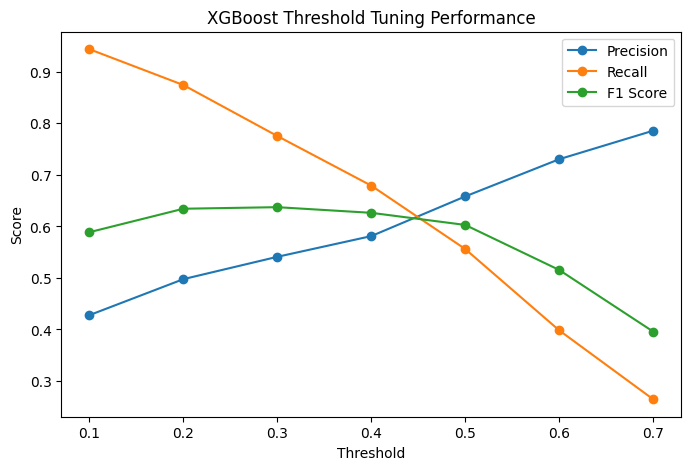

In [35]:
# Plot threshold tuning performance
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("XGBoost Threshold Tuning Performance")

plt.legend()

plt.show()

In [36]:
# Generate LightGBM churn probabilities
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

In [37]:
# Test multiple LightGBM thresholds
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

lgbm_threshold_results = []

for threshold in thresholds:
    lgbm_pred_threshold = (lgbm_prob >= threshold).astype(int)
    
    lgbm_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, lgbm_pred_threshold),
        "Recall": recall_score(y_test, lgbm_pred_threshold),
        "F1 Score": f1_score(y_test, lgbm_pred_threshold)
    })

lgbm_threshold_results_df = pd.DataFrame(lgbm_threshold_results)

In [38]:
# Format LightGBM threshold results
lgbm_threshold_results_df.style.format({
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}"
})

,Threshold,Precision,Recall,F1 Score
0,0.100000,0.420,0.933,0.580
1,0.200000,0.491,0.872,0.628
2,0.300000,0.538,0.786,0.639
3,0.400000,0.594,0.682,0.635
4,0.500000,0.666,0.548,0.601
5,0.600000,0.744,0.404,0.523
6,0.700000,0.794,0.267,0.400


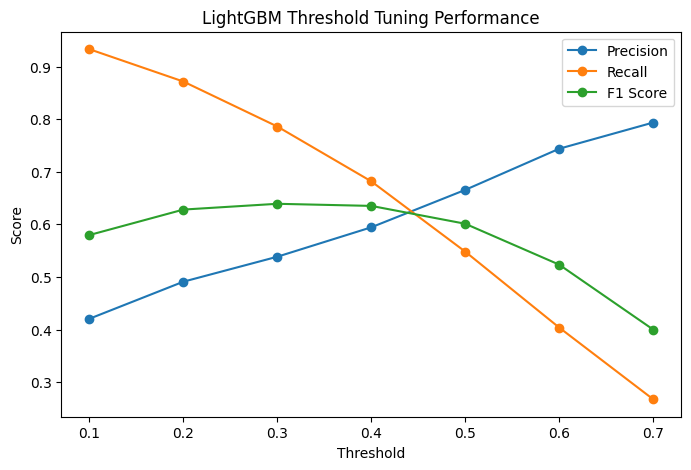

In [39]:
# Plot LightGBM threshold tuning performance
plt.figure(figsize=(8,5))

plt.plot(
    lgbm_threshold_results_df["Threshold"],
    lgbm_threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    lgbm_threshold_results_df["Threshold"],
    lgbm_threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    lgbm_threshold_results_df["Threshold"],
    lgbm_threshold_results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("LightGBM Threshold Tuning Performance")

plt.legend()

plt.show()

### 🔍 Tuned LightGBM Model Evaluation

In [40]:
# Apply selected LightGBM threshold
selected_threshold = 0.30

lgbm_tuned_pred = (lgbm_prob >= selected_threshold).astype(int)

In [41]:
# Evaluate tuned LightGBM predictions
print("Precision:", precision_score(y_test, lgbm_tuned_pred))
print("Recall:", recall_score(y_test, lgbm_tuned_pred))
print("F1 Score:", f1_score(y_test, lgbm_tuned_pred))

Precision: 0.5384615384615384
Recall: 0.786096256684492
F1 Score: 0.6391304347826087


In [42]:
# Display classification report
print(classification_report(y_test, lgbm_tuned_pred))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409



### 📝 Threshold Tuning Summary

Threshold tuning was performed to improve the churn detection capability of the advanced boosting models.

Instead of relying on the default probability threshold of 0.50, multiple thresholds were tested to evaluate the tradeoff between precision, recall, and F1-score.

### Key Observations

- Lower thresholds increased recall by identifying more potential churners.
- Higher thresholds increased precision but missed more actual churners.
- Both XGBoost and LightGBM achieved their strongest overall performance at a threshold of 0.30.

### Final Tuned Model

The tuned LightGBM model with a threshold of 0.30 achieved:

- Precision: 53.8%
- Recall: 78.6%
- F1 Score: 63.9%

Although the performance difference between XGBoost and LightGBM was small, LightGBM achieved slightly higher recall and F1-score after threshold tuning. Since customer churn prediction prioritizes identifying as many at-risk customers as possible, LightGBM was selected as the final tuned model.

The lower threshold increased false positives, but it significantly improved the model’s ability to detect actual churners compared to the default threshold of 0.50.

This demonstrates how threshold tuning can help align model behavior with business retention objectives rather than relying solely on default prediction settings.

## 🔍 SHAP Explainability

In [43]:
# Import SHAP library
import shap

In [44]:
# Create SHAP explainer for LightGBM
explainer = shap.TreeExplainer(lgbm_model)

shap_values = explainer.shap_values(X_test)

In [45]:
# Check SHAP values type and structure
type(shap_values)

numpy.ndarray

In [46]:
# Select SHAP values for churn class
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

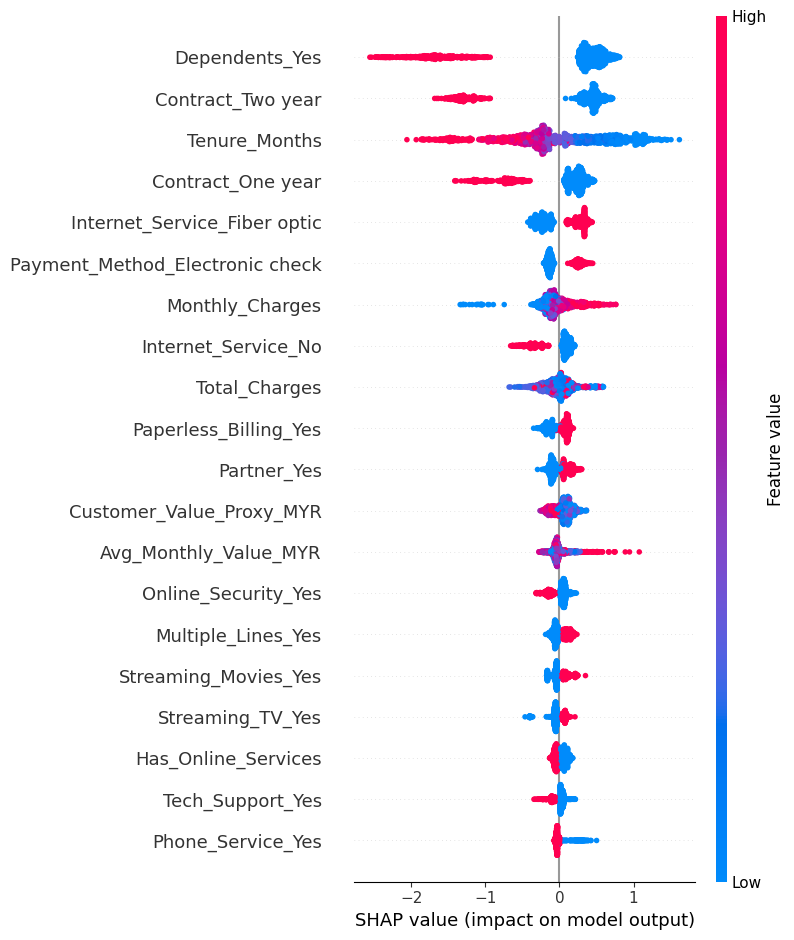

In [47]:
# Plot SHAP summary plot
shap.summary_plot(
    shap_values_churn,
    X_test,
    plot_type="dot"
)

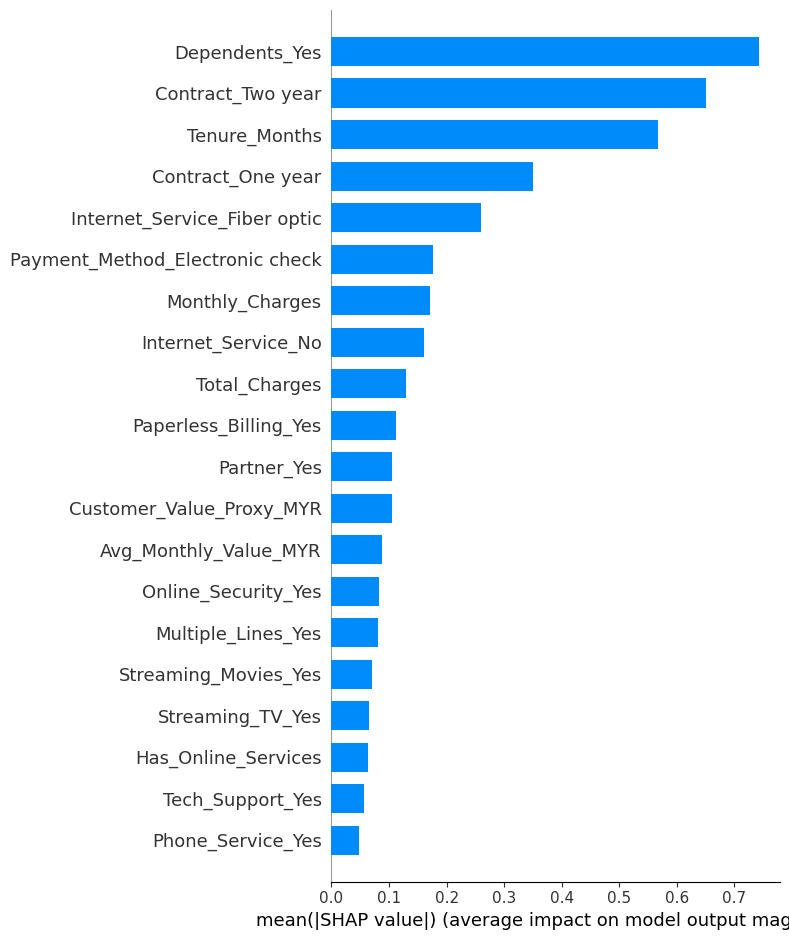

In [48]:
# Plot SHAP feature importance
shap.summary_plot(
    shap_values_churn,
    X_test,
    plot_type="bar"
)

In [49]:
# Select one customer for local explanation
customer_index = 0

customer = X_test.iloc[[customer_index]]

customer

,Tenure_Months,Monthly_Charges,Total_Charges,Customer_Value_Proxy_MYR,Avg_Monthly_Value_MYR,Service_Count,Has_Online_Services,Has_Streaming_Services,Gender_Male,Senior_Citizen_Yes,...,Contract_One year,Contract_Two year,Paperless_Billing_Yes,Payment_Method_Credit card (automatic),Payment_Method_Electronic check,Payment_Method_Mailed check,Tenure_Group_Mid-Term,Tenure_Group_New,Monthly_Charges_Level_Low,Monthly_Charges_Level_Medium
2196,72,114.05,8468.2,8211.6,116.00274,7,1,1,True,False,...,False,True,True,True,False,False,False,False,False,False


In [50]:
# Generate SHAP force plot for one customer
shap.initjs()

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    shap_values_churn[customer_index],
    customer
)

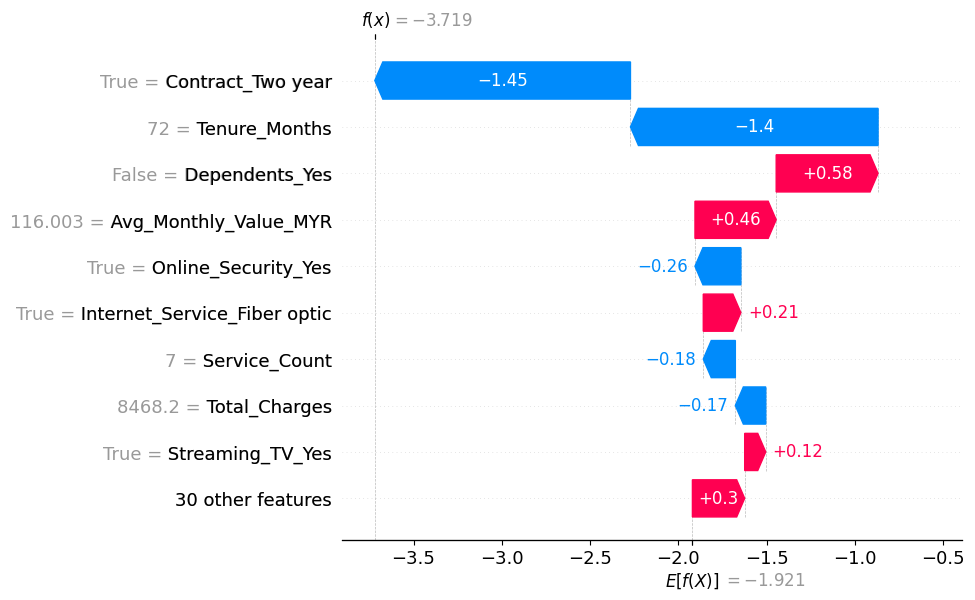

In [51]:
# Create waterfall plot for one customer
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_churn[customer_index],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=customer.iloc[0],
        feature_names=customer.columns
    )
)

### 📝 SHAP Explainability Summary

SHAP analysis was used to explain how the tuned LightGBM model makes churn predictions and identify the features with the strongest influence on customer churn.

### Key Observations

- Customers with longer tenure generally showed lower churn risk.
- Customers on one-year and two-year contracts were less likely to churn compared to month-to-month customers.
- Fiber optic internet customers contributed more strongly toward churn predictions.
- Customers using electronic checks showed higher churn tendency.
- Customers with dependents generally demonstrated lower churn risk.
- Higher monthly charges tended to increase churn probability.

The SHAP results were highly consistent with earlier EDA findings, feature importance analysis, and threshold tuning results, increasing confidence in the model’s interpretability and business relevance.

SHAP also helped explain individual customer predictions, making the model more transparent and easier to translate into retention-focused business decisions.

## 🚨 Enhanced Customer Risk Scoring

In [52]:
# Generate final churn probabilities
final_churn_prob = lgbm_model.predict_proba(X_test)[:, 1]

In [53]:
# Create customer risk scoring dataframe
risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test.values

risk_df["Churn_Probability"] = final_churn_prob

In [54]:
# Create churn risk tiers
def assign_risk_tier(probability):
    
    if probability >= 0.70:
        return "Critical Risk"
    
    elif probability >= 0.50:
        return "High Risk"
    
    elif probability >= 0.30:
        return "Medium Risk"
    
    else:
        return "Low Risk"

risk_df["Risk_Tier"] = risk_df["Churn_Probability"].apply(assign_risk_tier)

In [55]:
# Create retention priority levels
def assign_priority(tier):
    
    if tier == "Critical Risk":
        return "Immediate Action"
    
    elif tier == "High Risk":
        return "High Priority"
    
    elif tier == "Medium Risk":
        return "Monitor Closely"
    
    else:
        return "Low Priority"

risk_df["Retention_Priority"] = risk_df["Risk_Tier"].apply(assign_priority)

In [56]:
# Create business recommendations
def recommend_action(tier):
    
    if tier == "Critical Risk":
        return "Offer retention incentive immediately"
    
    elif tier == "High Risk":
        return "Target with retention campaign"
    
    elif tier == "Medium Risk":
        return "Monitor engagement and usage"
    
    else:
        return "No immediate intervention needed"

risk_df["Recommended_Action"] = risk_df["Risk_Tier"].apply(recommend_action)

In [57]:
# Check customer risk tier distribution
risk_df["Risk_Tier"].value_counts()

Risk_Tier
Low Risk         863
Medium Risk      238
High Risk        182
Critical Risk    126
Name: count, dtype: int64

In [58]:
# Risk tier percentage distribution
(
    risk_df["Risk_Tier"]
    .value_counts(normalize=True)
    * 100
).round(2)

Risk_Tier
Low Risk         61.25
Medium Risk      16.89
High Risk        12.92
Critical Risk     8.94
Name: proportion, dtype: float64

In [59]:
# Average churn probability by risk tier
risk_df.groupby("Risk_Tier")["Churn_Probability"].mean()

Risk_Tier
Critical Risk    0.802204
High Risk        0.590059
Low Risk         0.081442
Medium Risk      0.401267
Name: Churn_Probability, dtype: float64

In [60]:
# Actual churn rate by risk tier
risk_df.groupby("Risk_Tier")["Actual_Churn"].mean()

Risk_Tier
Critical Risk    0.793651
High Risk        0.576923
Low Risk         0.092700
Medium Risk      0.373950
Name: Actual_Churn, dtype: float64

In [61]:
# Check actual churn rate by risk tier
risk_df.groupby("Risk_Tier")["Actual_Churn"].mean().sort_values()

Risk_Tier
Low Risk         0.092700
Medium Risk      0.373950
High Risk        0.576923
Critical Risk    0.793651
Name: Actual_Churn, dtype: float64

In [62]:
# View highest-risk customers
risk_df[[
    "Churn_Probability",
    "Risk_Tier",
    "Retention_Priority",
    "Recommended_Action"
]].sort_values(
    by="Churn_Probability",
    ascending=False
).head(10)

,Churn_Probability,Risk_Tier,Retention_Priority,Recommended_Action
1203,0.922117,Critical Risk,Immediate Action,Offer retention incentive immediately
1818,0.919863,Critical Risk,Immediate Action,Offer retention incentive immediately
886,0.919438,Critical Risk,Immediate Action,Offer retention incentive immediately
684,0.915235,Critical Risk,Immediate Action,Offer retention incentive immediately
1756,0.912087,Critical Risk,Immediate Action,Offer retention incentive immediately
758,0.911149,Critical Risk,Immediate Action,Offer retention incentive immediately
590,0.911028,Critical Risk,Immediate Action,Offer retention incentive immediately
641,0.906350,Critical Risk,Immediate Action,Offer retention incentive immediately
579,0.893203,Critical Risk,Immediate Action,Offer retention incentive immediately
1782,0.892774,Critical Risk,Immediate Action,Offer retention incentive immediately


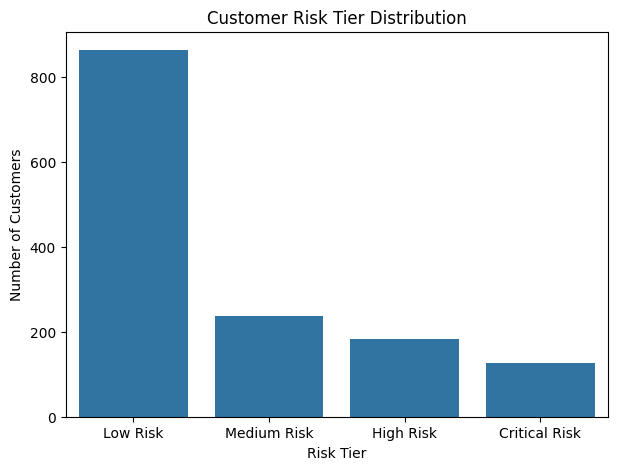

In [63]:
# Plot customer risk tier distribution
plt.figure(figsize=(7,5))

sns.countplot(
    data=risk_df,
    x="Risk_Tier",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Critical Risk"
    ]
)

plt.title("Customer Risk Tier Distribution")

plt.xlabel("Risk Tier")
plt.ylabel("Number of Customers")

plt.show()

### 📝 Enhanced Risk Scoring Summary

An enhanced customer risk scoring framework was created using churn probabilities generated by the tuned LightGBM model.

### Why Risk Scoring Was Added

- To transform raw churn probabilities into business-friendly customer risk categories.
- To help prioritize retention efforts based on predicted churn severity.
- To make model outputs more actionable for business decision-making.

### Risk Tier Distribution

Customers were grouped into four risk tiers:

- Low Risk: 61.3%
- Medium Risk: 16.9%
- High Risk: 12.9%
- Critical Risk: 8.9%

Each tier was assigned:
- a retention priority level
- a recommended business action

### Risk Tier Validation

The actual churn rate increased consistently across higher risk tiers:

- Low Risk: 9.3%
- Medium Risk: 37.4%
- High Risk: 57.7%
- Critical Risk: 79.4%

This indicates that the risk scoring framework aligned well with real customer churn behavior and successfully differentiated customers based on churn severity.

The framework helps translate machine learning predictions into clearer operational retention strategies and customer intervention planning.

## 👥 Customer Personas

In [64]:
# Create customer persona dataframe
persona_df = df.copy()

In [65]:
# Create customer personas
def assign_persona(row):
    
    if (
        row["Tenure_Months"] <= 12 and
        row["Monthly_Charges"] >= 70
    ):
        return "New High-Value Customer"
    
    elif (
        row["Contract"] == "Two year" and
        row["Tenure_Months"] >= 48
    ):
        return "Loyal Long-Term Customer"
    
    elif (
        row["Internet_Service"] == "Fiber optic" and
        row["Monthly_Charges"] >= 80
    ):
        return "High Usage Digital Customer"
    
    elif (
        row["Monthly_Charges"] < 40
    ):
        return "Budget-Conscious Customer"
    
    else:
        return "Standard Customer"

persona_df["Customer_Persona"] = persona_df.apply(
    assign_persona,
    axis=1
)

In [66]:
# Check customer persona distribution
persona_df["Customer_Persona"].value_counts()

Customer_Persona
Standard Customer              1896
High Usage Digital Customer    1536
Budget-Conscious Customer      1447
Loyal Long-Term Customer       1284
New High-Value Customer         880
Name: count, dtype: int64

In [67]:
# Analyze churn rate by persona
persona_churn = (
    persona_df
    .groupby("Customer_Persona")["Churn_Label"]
    .value_counts(normalize=True)
    .rename("Rate")
    .mul(100)
    .reset_index()
)

persona_churn

,Customer_Persona,Churn_Label,Rate
0,Budget-Conscious Customer,No,85.487215
1,Budget-Conscious Customer,Yes,14.512785
2,High Usage Digital Customer,No,65.690104
3,High Usage Digital Customer,Yes,34.309896
4,Loyal Long-Term Customer,No,96.651090
5,Loyal Long-Term Customer,Yes,3.348910
6,New High-Value Customer,Yes,68.068182
7,New High-Value Customer,No,31.931818
8,Standard Customer,No,74.156118
9,Standard Customer,Yes,25.843882


In [68]:
# Show churn percentage by persona
persona_churn_yes = (
    persona_churn[
        persona_churn["Churn_Label"] == "Yes"
    ]
    .sort_values(by="Rate", ascending=False)
)

persona_churn_yes

,Customer_Persona,Churn_Label,Rate
6,New High-Value Customer,Yes,68.068182
3,High Usage Digital Customer,Yes,34.309896
9,Standard Customer,Yes,25.843882
1,Budget-Conscious Customer,Yes,14.512785
5,Loyal Long-Term Customer,Yes,3.348910


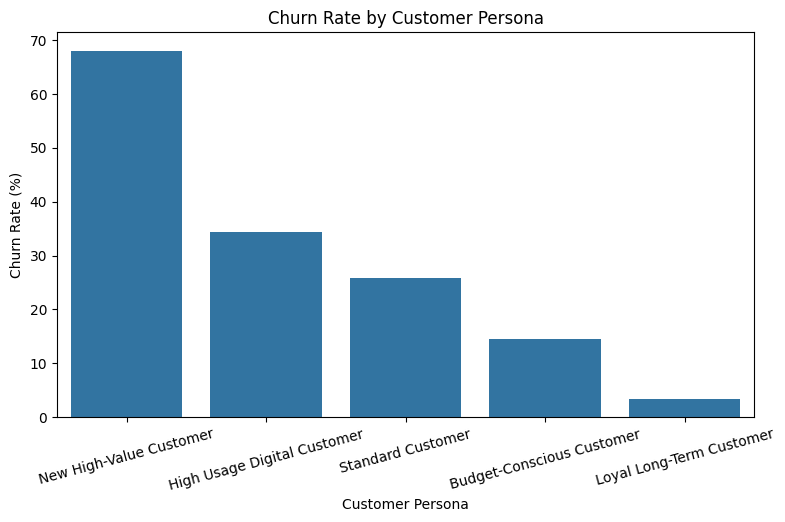

In [69]:
# Plot churn rate by customer persona
plt.figure(figsize=(9,5))

sns.barplot(
    data=persona_churn_yes,
    x="Customer_Persona",
    y="Rate"
)

plt.title("Churn Rate by Customer Persona")

plt.xlabel("Customer Persona")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

In [70]:
# Display persona churn insights
persona_churn_yes

,Customer_Persona,Churn_Label,Rate
6,New High-Value Customer,Yes,68.068182
3,High Usage Digital Customer,Yes,34.309896
9,Standard Customer,Yes,25.843882
1,Budget-Conscious Customer,Yes,14.512785
5,Loyal Long-Term Customer,Yes,3.348910


### 📝 Customer Persona Summary

Customer personas were created to group customers into more interpretable business-oriented segments based on service usage, tenure, contract behavior, and pricing characteristics.

### Why Personas Were Added

- To make churn analysis easier to interpret from a business perspective.
- To identify which customer groups demonstrate higher churn behavior.
- To support more targeted retention strategies and customer engagement planning.

### Persona Insights

- New High-Value Customers showed the highest churn rate at 68.1%, indicating that newer premium customers may require stronger onboarding and retention support.
- High Usage Digital Customers also demonstrated elevated churn behavior, suggesting possible dissatisfaction despite heavy service usage.
- Loyal Long-Term Customers showed the lowest churn rate at only 3.3%, confirming the stabilizing effect of long-term contracts and customer tenure.
- Budget-Conscious Customers demonstrated relatively low churn behavior, while Standard Customers showed moderate churn risk.

These persona groupings help translate machine learning predictions into clearer customer profiles that can support targeted retention campaigns and customer engagement strategies.

## ✅ Conclusion

This notebook extended the original telco churn project with advanced modeling, explainability, and business-focused customer analysis.

### Key Improvements

- Engineered additional behavioral and customer lifecycle features.
- Trained and compared XGBoost and LightGBM models.
- Applied threshold tuning to improve churn detection performance.
- Selected a tuned LightGBM model with a threshold of 0.30 for stronger recall and F1-score.
- Used SHAP explainability to identify key churn drivers.
- Built customer risk scoring and retention prioritization frameworks.
- Created customer personas to support targeted retention strategies.

### Overall Outcome

The project evolved beyond basic churn prediction by incorporating explainability, customer segmentation, and decision-focused business insights to support retention planning and customer intervention strategies.